# Mixed Linear Model

## Mixed-Effects Model
We use Mixed-Effects Model because simple ANOVA ignores:
- Same presentation appears in all 4 conditions
- Same LLM judge scoring repeatedly
- Correlation within presentations

**2 × 2 factorial design**:

- Factor 1: **Persona**
    - Academic
    - Pitch
- Factor 2: **Prompt Complexity**
    - Simple
    - Detailed
- Repeated across:
    - Multiple **presentations**
    - Multiple **evaluation dimensions**
        - grounding
        - actionability
        - persona consistency
        - toxicity

Let:

- ( $Y_{ij}$ ) = score for presentation *i* under condition *j*

Fixed effects:

- Persona (Academic vs Pitch)
- Complexity (Simple vs Detailed)
- Interaction (Persona × Complexity)

Random effects:

- Presentation (since each presentation appears multiple times)

**RQ1 - Persona x Presentation Type**

Presentation type:
- Academic talk
- Pitch

$$Y_{ij} = \beta_0 + \beta_1 Persona_j + \beta_2 Type_j +  \beta_3 (Persona_j \times Type_i) + u_i + \epsilon_{ij}$$


**RQ2 - Persona x Complexity:**

$$Y_{ij} = \beta_0 + \beta_1 \text{Complexity}_j + \beta_2 \text{Persona}_j + \beta_3 (\text{Complexity}_j \times \text{Persona}_j) + u_i + \epsilon_{ij}$$

Where:
- ($y_{ij}$): score for condition *i* on presentation *j*
- ($\beta$): fixed effects (what you test)
- ($u_j$): random effect for presentation
- ($\epsilon$): noise
* $u_i \sim \mathcal{N}(0, \sigma^2_u)$ &rarr; random intercept per presentation
* $\epsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$

Interpretation:
- ( $\beta_1$ ): effect of persona / prompt complexity
- ( $\beta_2$ ): effect of presentation type / prompt complexity
- ( $\beta_3$ ): interaction (Does the best persona depend on context or prompt design?)

**Report:**

- Fixed effects:
    - coefficient (β)
    - standard error
    - p-value
- Random effects:
    - variance (presentation) (TODO)
- Model fit:
    - AIC / BIC (TODO)


## Load scores


In [ ]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

## function to process results from scalar and pairwise evaluations into two separate dataframes
def process_results(file_path):
    all_rows = []
    pairwise_rows = []

    comparison_labels = [
        ("academic_simple", "academic_detailed"), # Index 0
        ("pitch_simple", "pitch_detailed"),       # Index 1
        ("academic_simple", "pitch_simple"),       # Index 2
        ("academic_detailed", "pitch_detailed")    # Index 3
    ]
    
    with open(file_path, "r") as f:
        for line in f:
            record = json.loads(line)

            # record contains: index, event, title, category, scalar, pairwise
            # each 'scalar' entry has 4 conditions: academic_simple, academic_detailed, etc.
            for cond_name, metrics in record["scalar"].items():
        
                if metrics:
                    # split condition name (e.g., 'academic_simple') into persona and complexity
                    persona, complexity = cond_name.split("_")
                    
                    all_rows.append({
                        'presentation_id': record["index"], # using index as ID
                        'type': record["category"],        # presentation type
                        'persona': persona,
                        'complexity': complexity,
                        'grounding': metrics.get('grounding'),
                        'actionability': metrics.get('actionability'),
                        'persona_consistency': metrics.get('persona_consistency'),
                        'clarity': metrics.get('clarity'),
                        'explanation': metrics.get('explanation')
                    })

            for i, res in enumerate(record["pairwise"]):
                if res and i < len(comparison_labels):
                    cond_a, cond_b = comparison_labels[i]
                    pairwise_rows.append({
                        'presentation_id': record["index"],
                        'presentation_type': record["category"],
                        'comparison': f"{cond_a}_vs_{cond_b}",
                        'model_a': cond_a,
                        'model_b': cond_b,
                        'better_grounding': res.get('better_grounding'),
                        'better_actionability': res.get('better_actionability'),
                        'better_clarity': res.get('better_clarity'),
                        'better_overall': res.get('better_overall'),
                        'explanation': res.get('explanation')
                    })
    
    return pd.DataFrame(all_rows), pd.DataFrame(pairwise_rows)





In [ ]:
# load and transform
df_scale, df_pair = process_results("llm_evaluation_results_checkpoint_gpt41_24.jsonl")
df_scale4o, df_pair4o = process_results("llm_evaluation_results_checkpoint_gpt4o_24.jsonl")
df_scale['avg_score'] = df_scale[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)
df_scale4o['avg_score'] = df_scale4o[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)
df_scale['condition'] = df_scale['persona'] + "_" + df_scale['complexity']
df_scale4o['condition'] = df_scale4o['persona'] + "_" + df_scale4o['complexity']
df_scale.iloc[60:80]

,presentation_id,type,persona,complexity,grounding,actionability,persona_consistency,clarity,explanation,avg_score,condition
60,15,academic,academic,simple,4.2,4.5,4.8,4.9,The feedback is well-grounded in the emotion t...,4.600,academic_simple
61,15,academic,academic,detailed,4.7,4.5,4.2,4.8,The feedback is closely aligned with the emoti...,4.550,academic_detailed
62,15,academic,pitch,simple,4.7,4.8,5.0,5.0,The feedback is deeply grounded in the emotion...,4.875,pitch_simple
63,15,academic,pitch,detailed,4.7,4.8,4.9,4.8,The feedback is closely tied to the emotion ti...,4.800,pitch_detailed
64,16,academic,academic,simple,4.7,4.8,5.0,4.9,The feedback is deeply grounded in the emotion...,4.850,academic_simple
65,16,academic,academic,detailed,4.7,4.5,5.0,4.8,The feedback is strongly grounded in the emoti...,4.750,academic_detailed
66,16,academic,pitch,simple,4.7,4.8,5.0,4.9,The feedback is deeply grounded in the emotion...,4.850,pitch_simple
67,16,academic,pitch,detailed,4.7,4.8,5.0,5.0,The feedback is strongly grounded in the emoti...,4.875,pitch_detailed
68,20,pitch,academic,simple,4.7,4.5,4.9,5.0,The feedback is deeply grounded in the emotion...,4.775,academic_simple
69,20,pitch,academic,detailed,4.7,4.6,5.0,4.9,The feedback is deeply grounded in the emotion...,4.800,academic_detailed


## Inspect scalar results

metric  presentation_id   domain          condition   persona complexity  \
0                     0  unknown  academic_detailed  academic   detailed   
1                     0  unknown    academic_simple  academic     simple   
2                     0  unknown     pitch_detailed     pitch   detailed   
3                     0  unknown       pitch_simple     pitch     simple   
4                     1  unknown  academic_detailed  academic   detailed   

metric  actionability  clarity  grounding  persona_consistency  composite  
0                 4.5      4.5        4.0                  4.5      4.375  
1                 4.5      4.5        4.0                  4.5      4.375  
2                 4.5      4.5        4.0                  4.5      4.375  
3                 4.5      4.5        4.0                  4.5      4.375  
4                 4.5      4.5        4.0                  5.0      4.500  

Dataset: 384 rows | 96 presentations | Domains: {'unknown': 384}


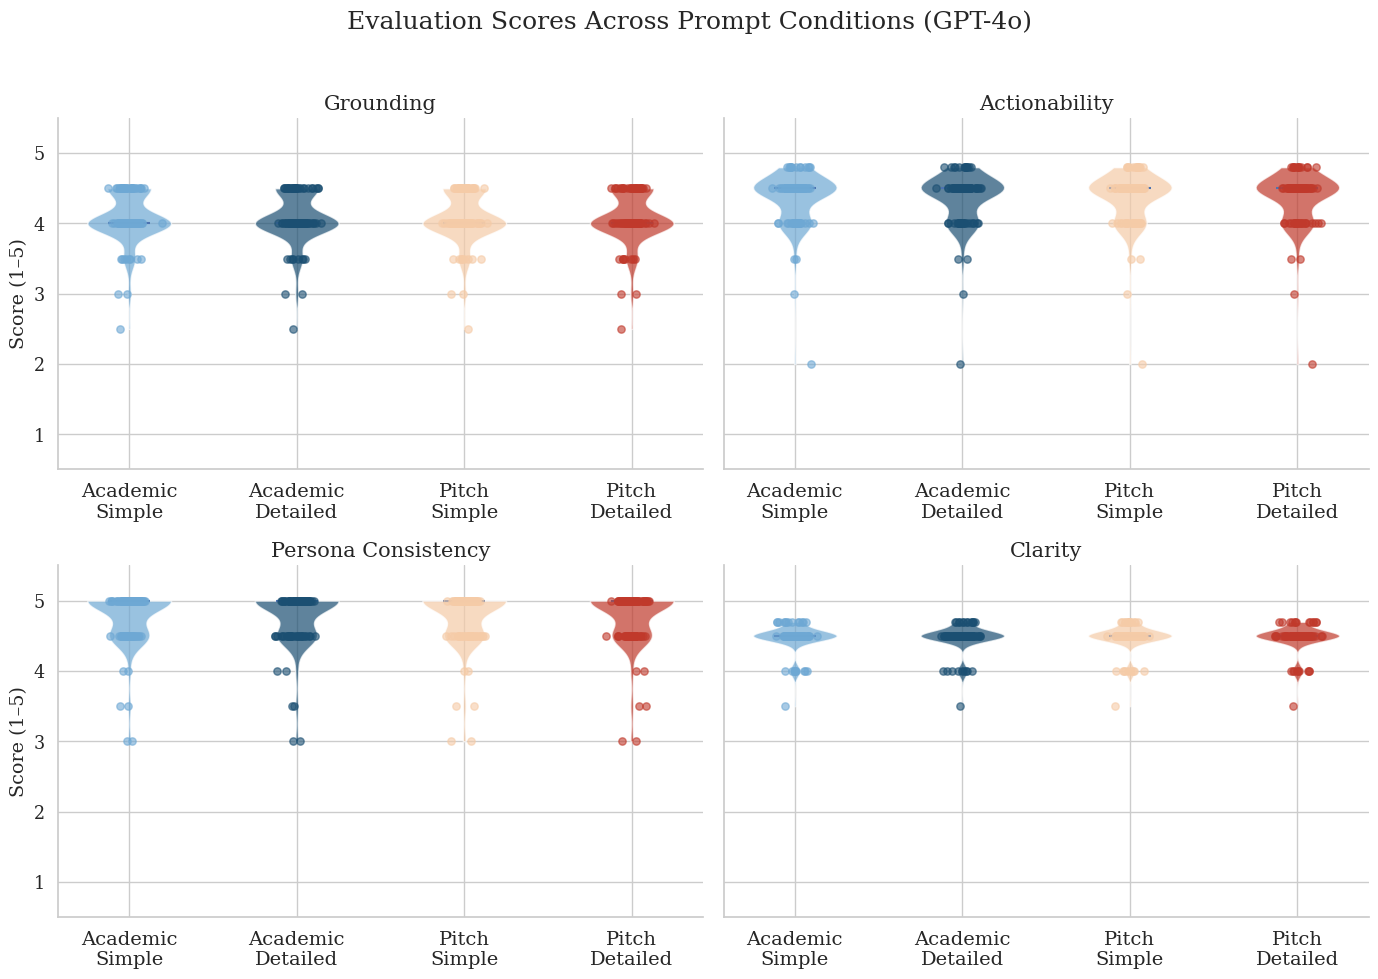

In [61]:
import numpy as np
import matplotlib.pyplot as plt

METRICS = ["grounding", "actionability", "persona_consistency", "clarity"]
CONDITIONS = ["academic_simple", "academic_detailed", "pitch_simple", "pitch_detailed"]


df = df_scale4o.copy()
# Melt to long format: one row per (presentation, condition, metric)
rows = []
for _, row in df.iterrows():
    for cond in CONDITIONS:
        for metric in METRICS:
            col = f"{metric}"  # adjust if your naming differs
            if col in df.columns:
                rows.append({
                    "presentation_id": row.get("title", _),
                    "domain": row.get("domain", "unknown"),
                    "condition": cond,
                    "persona": "academic" if "academic" in cond else "pitch",
                    "complexity": "detailed" if "detailed" in cond else "simple",
                    "metric": metric,
                    "score": row[col]
                })

df_long = pd.DataFrame(rows)

# Pivot to wide-metric format for convenience
df_wide = df_long.pivot_table(
    index=["presentation_id", "domain", "condition", "persona", "complexity"],
    columns="metric",
    values="score"
).reset_index()

# ── Composite score ─────────────────────────────────────────
# Invert toxicity (lower = better) before averaging
#df_wide["toxicity_inv"] = 6 - df_wide["toxicity"]
df_wide["composite"] = df_wide[
    ["grounding", "actionability", "persona_consistency", "clarity"]
].mean(axis=1)

print(df_wide.head())
print(f"\nDataset: {len(df_wide)} rows | "
      f"{df_wide['presentation_id'].nunique()} presentations | "
      f"Domains: {df_wide['domain'].value_counts().to_dict()}")

# ============================================================
# STYLE
# ============================================================
PALETTE = {
    "academic": "#2D6A9F",
    "pitch": "#E07B3F",
    "simple": "#A8C5DA",
    "detailed": "#F2B880",
    "academic_simple": "#6EA8D4",
    "academic_detailed": "#1B4F72",
    "pitch_simple": "#F5CBA7",
    "pitch_detailed": "#C0392B",
}

sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})



# ============================================================
# FIG 1 — 2x2 Score Distribution by Condition
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()  # convert 2x2 array -> 1D list

for ax, metric in zip(axes, METRICS):
    data_plot = [
        df_wide[df_wide["condition"] == cond][metric].dropna().values
        for cond in CONDITIONS
    ]

    # violin
    parts = ax.violinplot(
        data_plot,
        positions=range(len(CONDITIONS)),
        showmedians=True,
        showextrema=False
    )

    for pc, cond in zip(parts["bodies"], CONDITIONS):
        pc.set_facecolor(PALETTE[cond])
        pc.set_alpha(0.7)

    # scatter points
    for i, (cond, d) in enumerate(zip(CONDITIONS, data_plot)):
        ax.scatter(
            np.random.normal(i, 0.05, size=len(d)),
            d,
            color=PALETTE[cond],
            alpha=0.6,
            s=28,
            zorder=3
        )

    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels(
        ["Academic\nSimple", "Academic\nDetailed", "Pitch\nSimple", "Pitch\nDetailed"],
        fontsize=14
    )
    ax.set_title(metric.replace("_", " ").title(), fontsize=15)
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])

# Shared labels
for ax in axes[::2]:  # left column only
    ax.set_ylabel("Score (1–5)")

fig.suptitle(
    "Evaluation Scores Across Prompt Conditions (GPT-4o)",
    fontsize=18,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("fig1_distributions_2x2.pdf", bbox_inches="tight")
#plt.savefig("fig1_distributions_2x2.png", dpi=200, bbox_inches="tight")
plt.show()

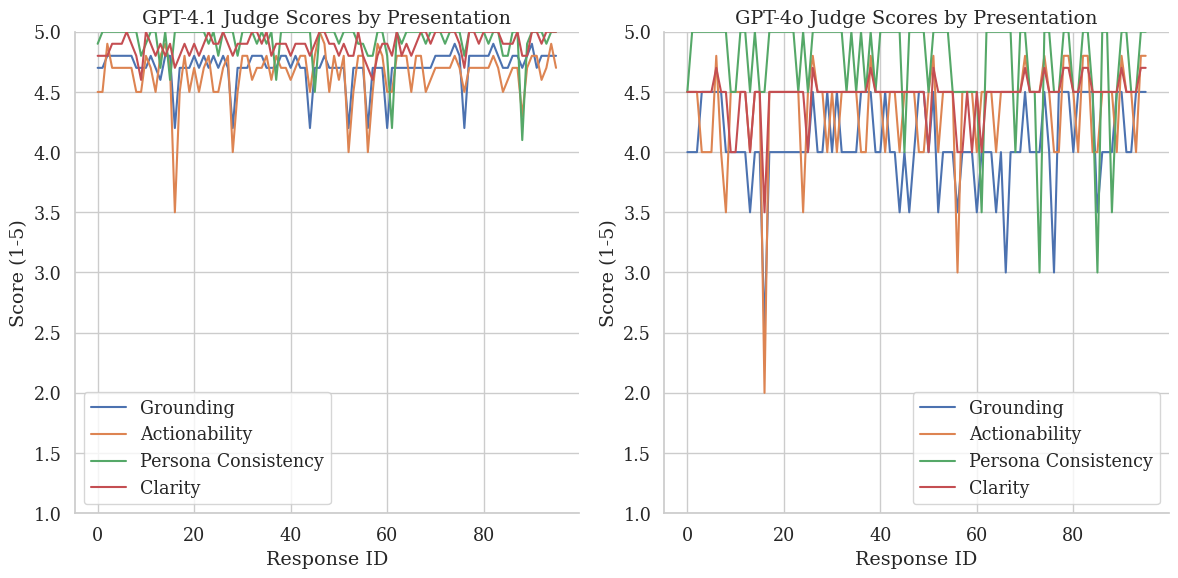

In [ ]:
# compare two plots 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("GPT-4.1 Judge Scores by Presentation")
plt.xlabel("Response ID")
plt.ylabel("Score (1-5)")
plt.ylim(1, 5)
df_scale['grounding'].plot(label='Grounding')
df_scale['actionability'].plot(label='Actionability')
df_scale['persona_consistency'].plot(label='Persona Consistency')
df_scale['clarity'].plot(label='Clarity')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("GPT-4o Judge Scores by Presentation")
plt.xlabel("Response ID")
plt.ylabel("Score (1-5)")
plt.ylim(1, 5)
df_scale4o['grounding'].plot(label='Grounding')
df_scale4o['actionability'].plot(label='Actionability')
df_scale4o['persona_consistency'].plot(label='Persona Consistency')
df_scale4o['clarity'].plot(label='Clarity')
plt.legend()
plt.tight_layout()
plt.show()



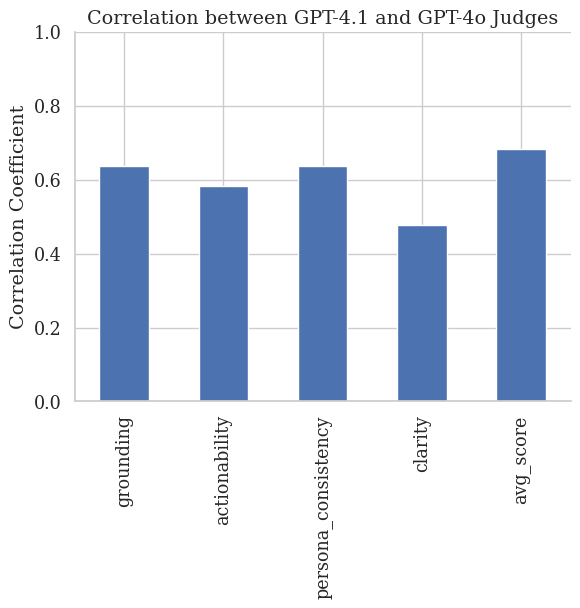

grounding              0.636148
actionability          0.583694
persona_consistency    0.637986
clarity                0.478311
avg_score              0.681943
dtype: float64

In [72]:
# measure correlation between the two judges
correlation = df_scale[['grounding', 'actionability', 'persona_consistency', 'clarity', 'avg_score']].corrwith(df_scale4o[['grounding', 'actionability', 'persona_consistency', 'clarity', 'avg_score']])

# plot correlation
correlation.plot(kind='bar', title='Correlation between GPT-4.1 and GPT-4o Judges')
plt.ylabel('Correlation Coefficient')
plt.ylim(0, 1)
plt.show()

correlation


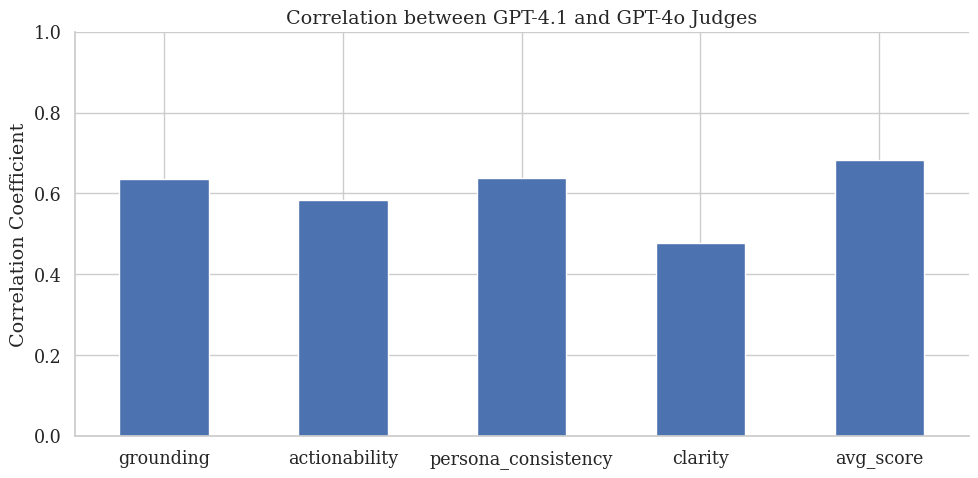

grounding              0.636148
actionability          0.583694
persona_consistency    0.637986
clarity                0.478311
avg_score              0.681943
dtype: float64

In [79]:
import matplotlib.pyplot as plt

# measure correlation between the two judges
correlation = df_scale[['grounding', 'actionability', 'persona_consistency', 'clarity', 'avg_score']].corrwith(
    df_scale4o[['grounding', 'actionability', 'persona_consistency', 'clarity', 'avg_score']]
)

# plot correlation with adjusted figure size and horizontal labels (rot=0)
correlation.plot(
    kind='bar', 
    title='Correlation between GPT-4.1 and GPT-4o Judges',
    figsize=(10, 5),
    rot=0
)

plt.ylabel('Correlation Coefficient')
plt.ylim(0, 1)

# Optional: cleans up layout spacing so long labels like 'persona_consistency' don't get cut off
plt.tight_layout() 

plt.show()

correlation

In [ ]:

df_scale['avg_score'] = df_scale[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)
df_scale["persona"] = df_scale["persona"].astype("category")
df_scale["complexity"] = df_scale["complexity"].astype("category")
df_scale["type"] = df_scale["type"].astype("category")
df_scale["presentation_id"] = df_scale["presentation_id"].astype("category")

### RQ1: Effect of Persona in Presentation Type

In [54]:
df_combined

,presentation_id,type,persona,complexity,grounding,actionability,persona_consistency,clarity,explanation,avg_score,condition
0,0,academic,academic,simple,4.7,4.5,4.9,4.8,The feedback is deeply grounded in the emotion...,4.5500,academic_simple
1,0,academic,academic,detailed,4.7,4.5,5.0,4.8,The feedback is strongly grounded in the emoti...,4.6250,academic_detailed
2,0,academic,pitch,simple,4.8,4.9,5.0,4.8,The feedback is deeply grounded in the emotion...,4.6875,pitch_simple
3,0,academic,pitch,detailed,4.8,4.7,5.0,4.9,The feedback is tightly aligned with the emoti...,4.6750,pitch_detailed
4,1,academic,academic,simple,4.8,4.7,5.0,4.9,The feedback is deeply grounded in the emotion...,4.6750,academic_simple
...,...,...,...,...,...,...,...,...,...,...,...
91,26,pitch,pitch,detailed,4.7,4.8,5.0,5.0,The feedback is strongly grounded in the emoti...,4.6875,pitch_detailed
92,27,pitch,academic,simple,4.8,4.6,5.0,4.9,The feedback is deeply grounded in the emotion...,4.6000,academic_simple
93,27,pitch,academic,detailed,4.8,4.7,4.9,5.0,The feedback is deeply grounded in the emotion...,4.6125,academic_detailed
94,27,pitch,pitch,simple,4.8,4.9,5.0,5.0,The feedback is deeply grounded in the emotion...,4.8375,pitch_simple


## RQ1: Persona x Type
avg_score, persona_consistency

In [74]:
df_combined = df_scale.copy()
df_combined['persona_consistency'] = (df_scale['persona_consistency'] + df_scale4o['persona_consistency']) / 2
df_combined['avg_score'] = (df_scale['avg_score'] + df_scale4o['avg_score']) / 2

# run one model on the consensus score
model_consensus = smf.mixedlm(
    "avg_score ~ persona * type", 
    data=df_combined, 
    groups=df_combined["presentation_id"]
).fit()

print(model_consensus.summary())

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       avg_score
No. Observations:        96            Method:                   REML     
No. Groups:              24            Scale:                    0.0173   
Min. group size:         4             Log-Likelihood:           46.2191  
Max. group size:         4             Converged:                Yes      
Mean group size:         4.0                                              
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       4.519    0.025 183.067 0.000  4.471  4.568
persona[T.pitch]                0.142    0.032   4.434 0.000  0.079  0.204
type[T.pitch]                  -0.001    0.046  -0.028 0.978 -0.091  0.088
persona[T.pitch]:type[T.pitch]  0.108    0.0

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [75]:
# run one model on the consensus score
model_consensus = smf.mixedlm(
    "avg_score ~ persona * type", 
    data=df_combined, 
    groups=df_combined["presentation_id"]
).fit()

print(model_consensus.summary())

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       avg_score
No. Observations:        96            Method:                   REML     
No. Groups:              24            Scale:                    0.0173   
Min. group size:         4             Log-Likelihood:           46.2191  
Max. group size:         4             Converged:                Yes      
Mean group size:         4.0                                              
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       4.519    0.025 183.067 0.000  4.471  4.568
persona[T.pitch]                0.142    0.032   4.434 0.000  0.079  0.204
type[T.pitch]                  -0.001    0.046  -0.028 0.978 -0.091  0.088
persona[T.pitch]:type[T.pitch]  0.108    0.0

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## RQ2: Complexity x Persona
avg_score, actionability, clarity

In [78]:
model_consensus = smf.mixedlm(
    "clarity ~ complexity * persona", 
    data=df_combined, 
    groups=df_combined["presentation_id"]
).fit()

print(model_consensus.summary())

                      Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          clarity
No. Observations:           96               Method:                      REML   
No. Groups:                 24               Scale:                       0.0053 
Min. group size:            4                Log-Likelihood:              92.1216
Max. group size:            4                Converged:                   Yes    
Mean group size:            4.0                                                  
---------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              4.867    0.018 271.157 0.000  4.831  4.902
complexity[T.simple]                  -0.012    0.021  -0.594 0.552 -0.054  0.029
persona[T.pitch]                      

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [53]:
import statsmodels.formula.api as smf

df_combined = df_scale.copy()
df_combined['avg_score'] = (df_scale['avg_score'] + df_scale4o['avg_score']) / 2

# run one model on the consensus score
model_consensus = smf.mixedlm(
    "avg_score ~ persona * type", 
    data=df_combined, 
    groups=df_combined["presentation_id"]
).fit()

print(model_consensus.summary())



                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       avg_score
No. Observations:        96            Method:                   REML     
No. Groups:              24            Scale:                    0.0173   
Min. group size:         4             Log-Likelihood:           46.2191  
Max. group size:         4             Converged:                Yes      
Mean group size:         4.0                                              
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       4.519    0.025 183.067 0.000  4.471  4.568
persona[T.pitch]                0.142    0.032   4.434 0.000  0.079  0.204
type[T.pitch]                  -0.001    0.046  -0.028 0.978 -0.091  0.088
persona[T.pitch]:type[T.pitch]  0.108    0.0

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [65]:
# grounding
model_balanced = smf.mixedlm(
    "grounding ~ C(persona, Sum) * C(type, Sum)", 
    data=df, 
    groups=df["presentation_id"]
).fit()

print("grounding",model_balanced.summary())

# actionability
model_balanced = smf.mixedlm(
    "actionability ~ C(persona, Sum) * C(type, Sum)", 
    data=df, 
    groups=df["presentation_id"]
).fit()

print("actionability",model_balanced.summary())

# persona_consistency
model_balanced = smf.mixedlm(
    "persona_consistency ~ C(persona, Sum) * C(type, Sum)", 
    data=df, 
    groups=df["presentation_id"]
).fit()

print("persona_consistency",model_balanced.summary())

# clarity
model_balanced = smf.mixedlm(
    "clarity ~ C(persona, Sum) * C(type, Sum)", 
    data=df, 
    groups=df["presentation_id"]
).fit()

print("clarity",model_balanced.summary())

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


grounding                              Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              grounding
No. Observations:                96                   Method:                          REML     
No. Groups:                      24                   Scale:                           0.0188   
Min. group size:                 4                    Log-Likelihood:                  40.4618  
Max. group size:                 4                    Converged:                       Yes      
Mean group size:                 4.0                                                            
------------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                         

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


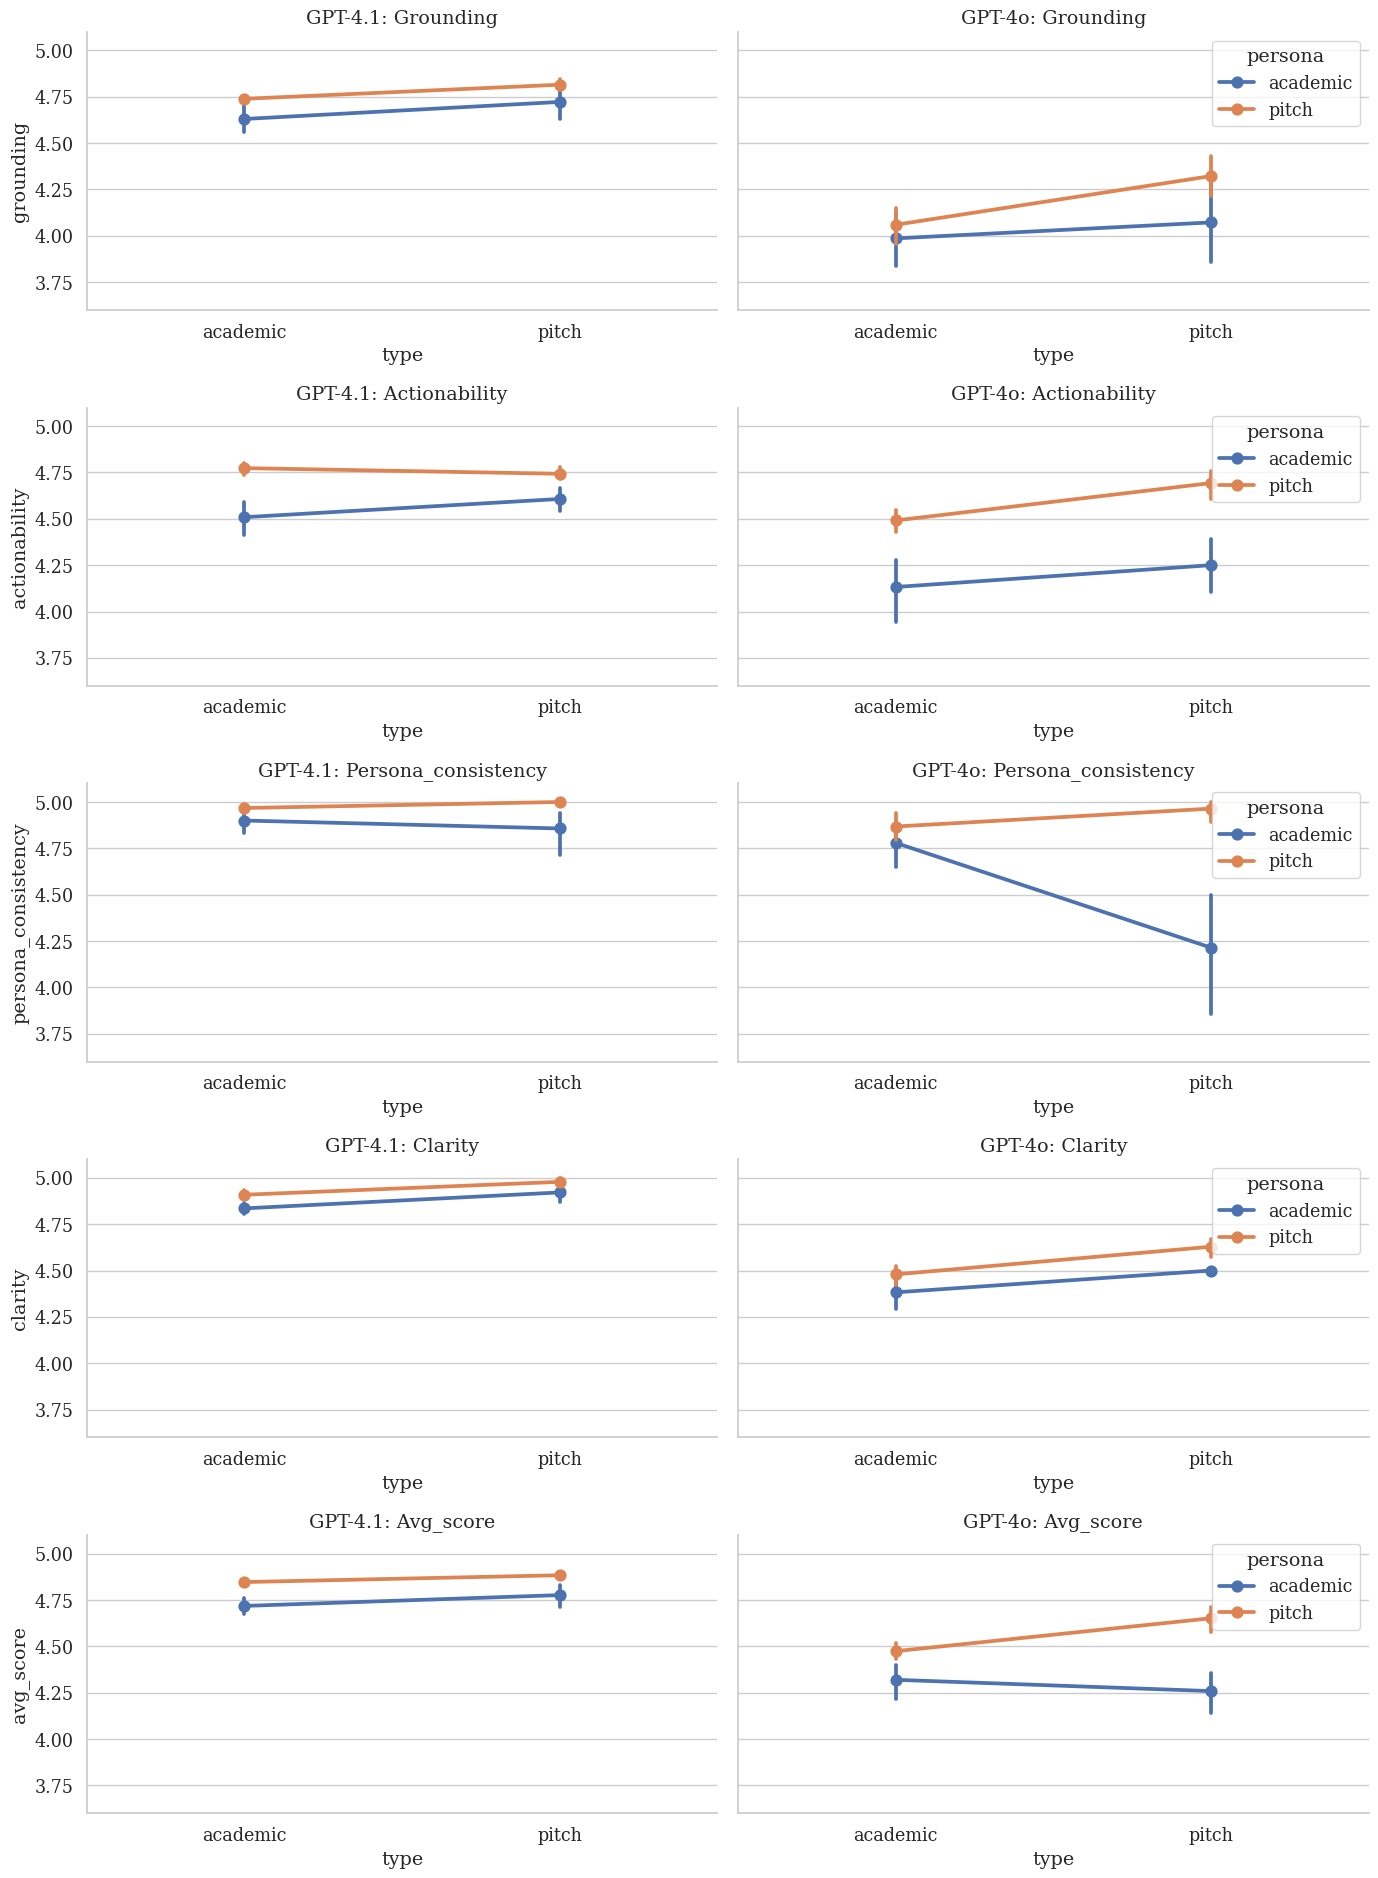

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


df_scale['avg_score'] = df_scale[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)
df_scale4o['avg_score'] = df_scale4o[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)

metrics = ["grounding", "actionability", "persona_consistency", "clarity", "avg_score"]

# We create a grid: Rows = Metrics, Cols = 2 (Left: GPT-4.1, Right: GPT-4o)
fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 20), sharey=True)

for i, metric in enumerate(metrics):
    # --- Column 1: GPT-4.1 ---
    sns.pointplot(
        data=df_scale,
        x="type",
        y=metric,
        hue="persona",
        #linestyles="-",
        #markers="o",
        ax=axes[i, 0],
        legend=False

    )
    axes[i, 0].set_title(f"GPT-4.1: {metric.capitalize()}")
    axes[i, 0].set_ylim(3.6, 5.1) # Adjusted slightly for visibility
    
    # --- Column 2: GPT-4o ---
    sns.pointplot(
        data=df_scale4o,
        x="type",
        y=metric,
        hue="persona",
        #linestyles="--",
        #markers="s",
        ax=axes[i, 1],

    )
    
    axes[i, 1].set_title(f"GPT-4o: {metric.capitalize()}")

# add one global legend at the bottom
#handles, labels = axes[0, 0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02), fontsize='large')

# Adjust layout to make room for the bottom legend
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()

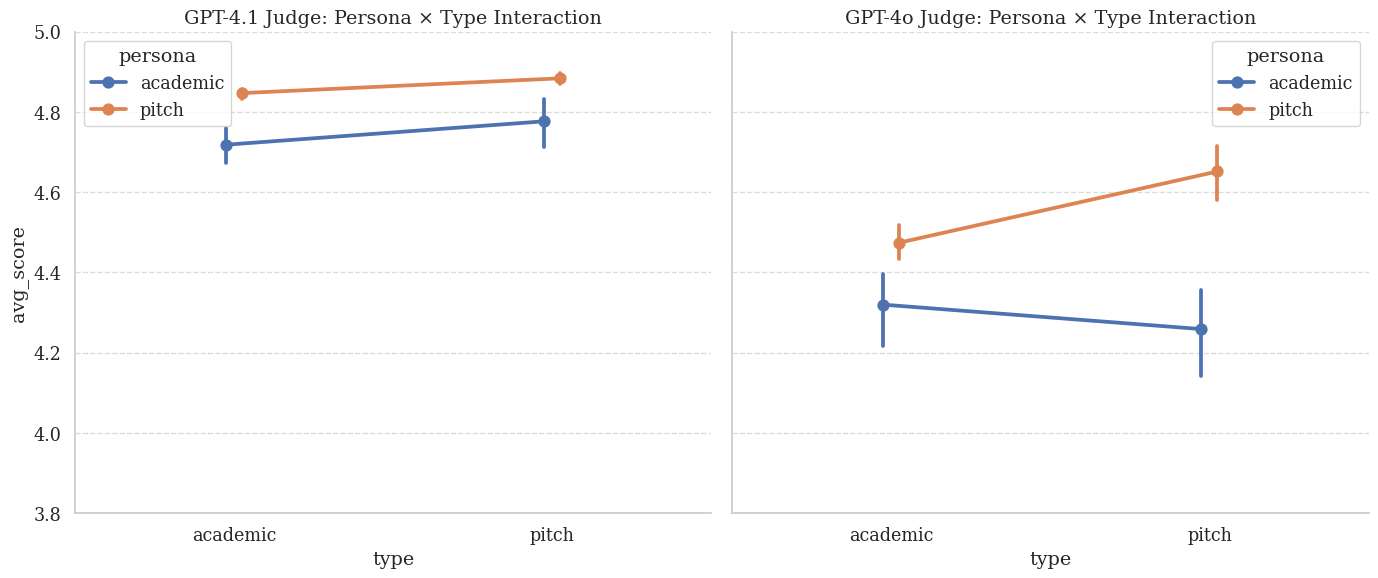

In [37]:
# Create a figure with 1 row and 2 columns
# sharey=True ensures both plots use the exact same vertical scale
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Plot 1: GPT-4.1 (Left) ---
sns.pointplot(
    data=df_scale,
    x="type",
    y="avg_score",  # Replace with the specific metric you want to show
    hue="persona",
    dodge=True,
    ax=axes[0]
)
axes[0].set_title("GPT-4.1 Judge: Persona × Type Interaction")
axes[0].set_ylim(1, 5) # Set full rubric scale
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: GPT-4o (Right) ---
sns.pointplot(
    data=df_scale4o,
    x="type",
    y="avg_score",  # Must be the same metric as above
    hue="persona",
    dodge=True,
    ax=axes[1]
)
axes[1].set_title("GPT-4o Judge: Persona × Type Interaction")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Remove the redundant y-label on the second plot
axes[1].set_ylabel("")

# Improve layout
plt.tight_layout()

# Save the combined figure for your LaTeX document
plt.ylim(3.8, 5) # Ensure both plots have the same y-axis limits
plt.savefig("combined_persona_interaction.png", dpi=300)
plt.show()

In [ ]:
df = df_scale.copy()
df['condition'] = df['persona'] + "_" + df['complexity']
sns.pointplot(
    data=df,
    x="type",
    y="score",
    hue="condition",
    dodge=True
)
plt.ylim(4.3, 5)
plt.title("Interaction: Condition × Type (GPT-4.1)")
plt.show()

<Axes: xlabel='persona', ylabel='score'>

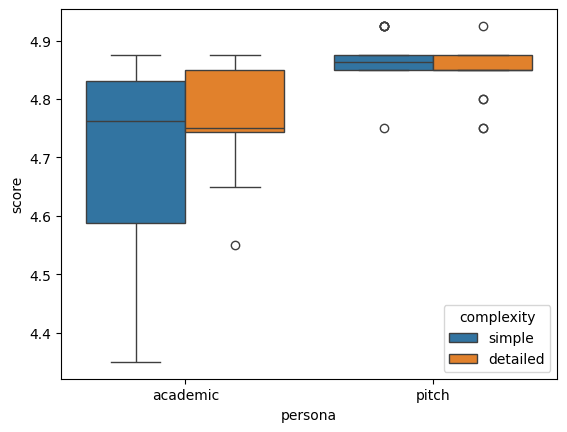

In [67]:
sns.boxplot(
    data=df_scale,
    x="persona",
    y="score",
    hue="complexity"
)

In [55]:
# Assuming 'df' is your results dataframe
# Group by the transcript ID (group) and calculate variance
variance_check = df.groupby('presentation_id')[['grounding', 'actionability']].var()

# Sort to see the most inconsistent transcripts
print(variance_check.sort_values(by='grounding', ascending=False).head(10))


                 grounding  actionability
presentation_id                          
4                 0.562500       1.562500
23                0.562500       0.213333
16                0.229167       0.062500
25                0.166667       0.083333
7                 0.083333       0.083333
11                0.083333       0.062500
26                0.083333       0.110000
24                0.062500       0.142500
10                0.062500       0.062500
27                0.062500       0.142500


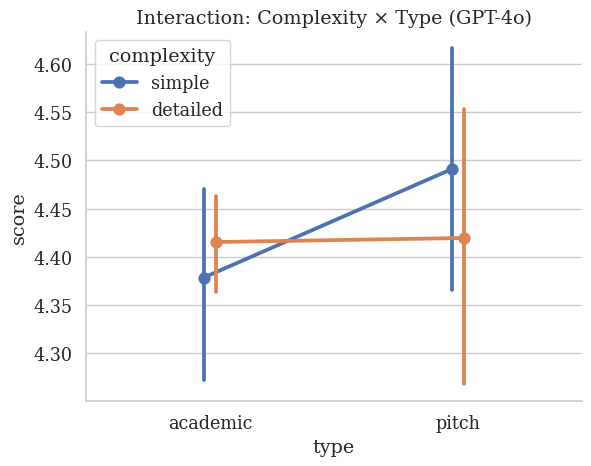

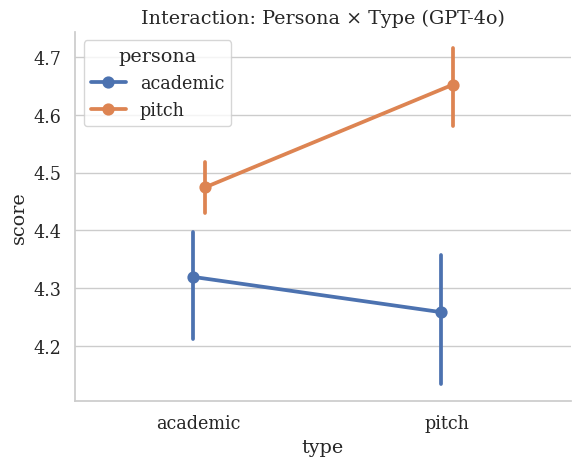

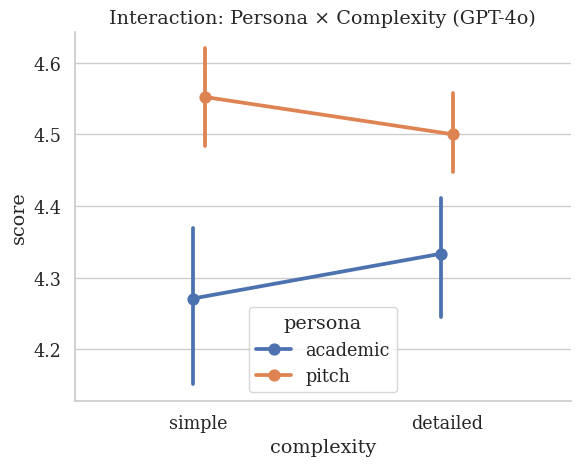

In [177]:
sns.pointplot(
    data=df,
    x="type",
    y="score",
    hue="complexity",
    dodge=True
)

plt.title("Interaction: Complexity × Type (GPT-4o)")
plt.show()

sns.pointplot(
    data=df,
    x="type",
    y="score",
    hue="persona",
    dodge=True
)

plt.title("Interaction: Persona × Type (GPT-4o)")
plt.show()

sns.pointplot(
    data=df,
    x="complexity",
    y="score",
    hue="persona",
    dodge=True
)

plt.title("Interaction: Persona × Complexity (GPT-4o)")
plt.show()

### RQ2: Effect of Complexity in Persona

In [ ]:

# merge the dataframes on the unique identifier 
# assuming both DFs have the same rows in the same order
df_combined = df_scale.copy()

df_combined['grounding'] = (df_scale['grounding'] + df_scale4o['grounding']) / 2
df_combined['actionability'] = (df_scale['actionability'] + df_scale4o['actionability']) / 2
df_combined['persona_consistency'] = (df_scale['persona_consistency'] + df_scale4o['persona_consistency']) / 2      
df_combined['clarity'] = (df_scale['clarity'] + df_scale4o['clarity']) / 2
df_combined['avg_score'] = df_combined[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)

model = smf.mixedlm(
    "actionability ~ persona * type", 
    data=df_combined, 
    groups=df_combined["presentation_id"]
).fit(method=["nm"]) # Nelder-Mead is gentler on boundary data
# ).fit()
print(model.summary())

                  Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       clarity
No. Observations:         96            Method:                   REML   
No. Groups:               24            Scale:                    0.0098 
Min. group size:          4             Log-Likelihood:           67.9172
Max. group size:          4             Converged:                Yes    
Mean group size:          4.0                                            
-------------------------------------------------------------------------
                               Coef. Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      4.609    0.021 217.802 0.000  4.567  4.650
persona[T.pitch]               0.085    0.024   3.556 0.000  0.038  0.132
type[T.pitch]                  0.102    0.039   2.600 0.009  0.025  0.179
persona[T.pitch]:type[T.pitch] 0.008    0.044   0.170 0.

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:


# run one model on the consensus score
model_consensus = smf.mixedlm(
    "avg_score ~ complexity * persona", 
    data=df_scale, 
    groups=df_combined["presentation_id"]
).fit()

print(model_consensus.summary())

# run one model on the consensus score
model_consensus = smf.mixedlm(
    "avg_score ~ complexity * persona", 
    data=df_scale4o, 
    groups=df_combined["presentation_id"]
).fit()

print(model_consensus.summary())

                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         avg_score
No. Observations:           96              Method:                     REML     
No. Groups:                 24              Scale:                      0.0070   
Min. group size:            4               Log-Likelihood:             84.2195  
Max. group size:            4               Converged:                  Yes      
Mean group size:            4.0                                                  
---------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              4.770    0.019 253.569 0.000  4.733  4.807
complexity[T.simple]                  -0.069    0.024  -2.843 0.004 -0.116 -0.021
persona[T.pitch]                      

/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/sofiafernandes/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


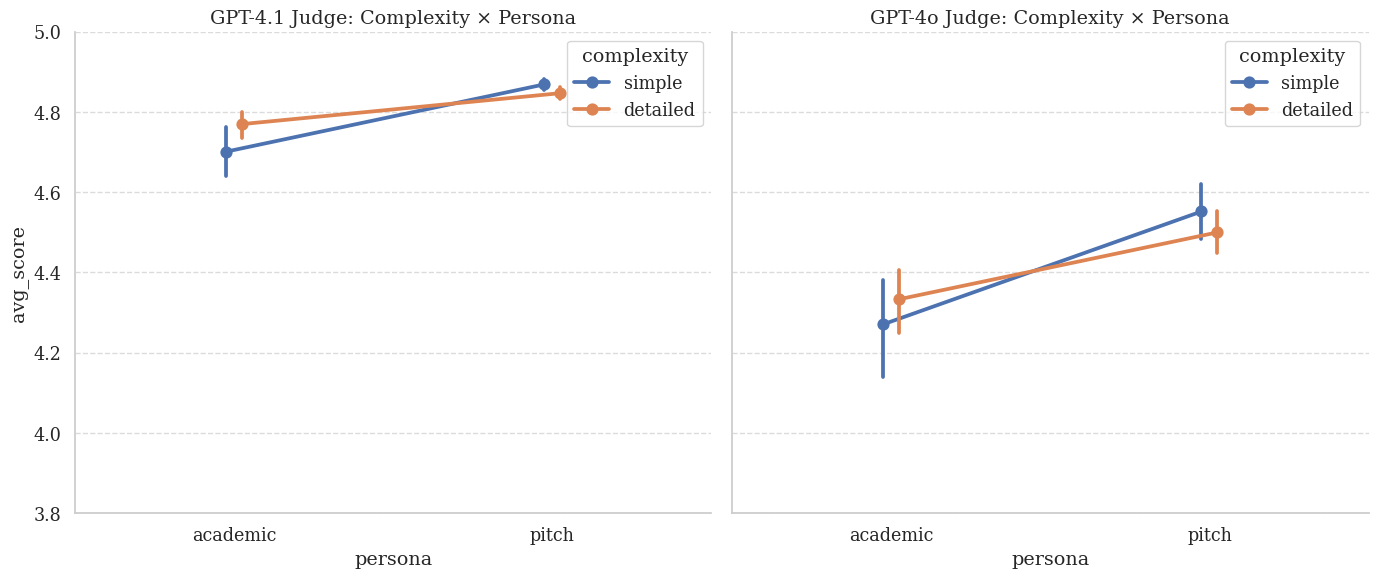

In [ ]:

# Create a figure with 1 row and 2 columns
# sharey=True ensures both plots use the exact same vertical scale
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Plot 1: GPT-4.1 (Left) ---
sns.pointplot(
    data=df_scale,
    x="persona",
    y="avg_score",  # Replace with the specific metric you want to show
    hue="complexity",
    hue_order=["simple", "detailed"],  # Ensure consistent hue order
    dodge=True,
    ax=axes[0]
)
axes[0].set_title("GPT-4.1 Judge: Complexity × Persona")
#axes[0].set_ylim(1, 5) # Set full rubric scale
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: GPT-4o (Right) ---
sns.pointplot(
    data=df_scale4o,
    x="persona",
    y="avg_score",  # Must be the same metric as above
    hue="complexity",
    hue_order=["simple", "detailed"],  # Ensure consistent hue order
    dodge=True,
    ax=axes[1]
)
axes[1].set_title("GPT-4o Judge: Complexity × Persona")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Remove the redundant y-label on the second plot
axes[1].set_ylabel("")

# Improve layout
plt.tight_layout()

# Save the combined figure for your LaTeX document
plt.ylim(3.8, 5) # Ensure both plots have the same y-axis limits
plt.savefig("combined_persona_interaction.png", dpi=300)
plt.show()

In [14]:
df_pair

,presentation_id,presentation_type,comparison,model_a,model_b,better_grounding,better_actionability,better_clarity,better_overall,explanation
0,0,academic,academic_simple_vs_academic_detailed,academic_simple,academic_detailed,A,A,A,A,Response A provides a more nuanced and emotion...
1,0,academic,pitch_simple_vs_pitch_detailed,pitch_simple,pitch_detailed,A,A,A,A,Response A provides a more nuanced and detaile...
2,0,academic,academic_simple_vs_pitch_simple,academic_simple,pitch_simple,B,B,B,B,Response B better reflects the emotional dynam...
3,0,academic,academic_detailed_vs_pitch_detailed,academic_detailed,pitch_detailed,A,B,B,B,Response A provides a more nuanced and detaile...
4,1,academic,academic_simple_vs_academic_detailed,academic_simple,academic_detailed,A,A,B,A,Response A provides a more nuanced and emotion...
...,...,...,...,...,...,...,...,...,...,...
91,26,pitch,academic_detailed_vs_pitch_detailed,academic_detailed,pitch_detailed,A,A,A,A,Response A provides a more nuanced and emotion...
92,27,pitch,academic_simple_vs_academic_detailed,academic_simple,academic_detailed,A,A,B,A,Response A provides a more thorough and nuance...
93,27,pitch,pitch_simple_vs_pitch_detailed,pitch_simple,pitch_detailed,A,A,B,A,Response A provides a more nuanced and emotion...
94,27,pitch,academic_simple_vs_pitch_simple,academic_simple,pitch_simple,B,B,B,B,Response B better reflects the emotional dynam...


In [13]:
df_scale

,presentation_id,type,persona,complexity,grounding,actionability,persona_consistency,clarity,explanation,avg_score
0,0,academic,academic,simple,4.7,4.5,4.9,4.8,The feedback is deeply grounded in the emotion...,4.725
1,0,academic,academic,detailed,4.7,4.5,5.0,4.8,The feedback is strongly grounded in the emoti...,4.750
2,0,academic,pitch,simple,4.8,4.9,5.0,4.8,The feedback is deeply grounded in the emotion...,4.875
3,0,academic,pitch,detailed,4.8,4.7,5.0,4.9,The feedback is tightly aligned with the emoti...,4.850
4,1,academic,academic,simple,4.8,4.7,5.0,4.9,The feedback is deeply grounded in the emotion...,4.850
...,...,...,...,...,...,...,...,...,...,...
91,26,pitch,pitch,detailed,4.7,4.8,5.0,5.0,The feedback is strongly grounded in the emoti...,4.875
92,27,pitch,academic,simple,4.8,4.6,5.0,4.9,The feedback is deeply grounded in the emotion...,4.825
93,27,pitch,academic,detailed,4.8,4.7,4.9,5.0,The feedback is deeply grounded in the emotion...,4.850
94,27,pitch,pitch,simple,4.8,4.9,5.0,5.0,The feedback is deeply grounded in the emotion...,4.925


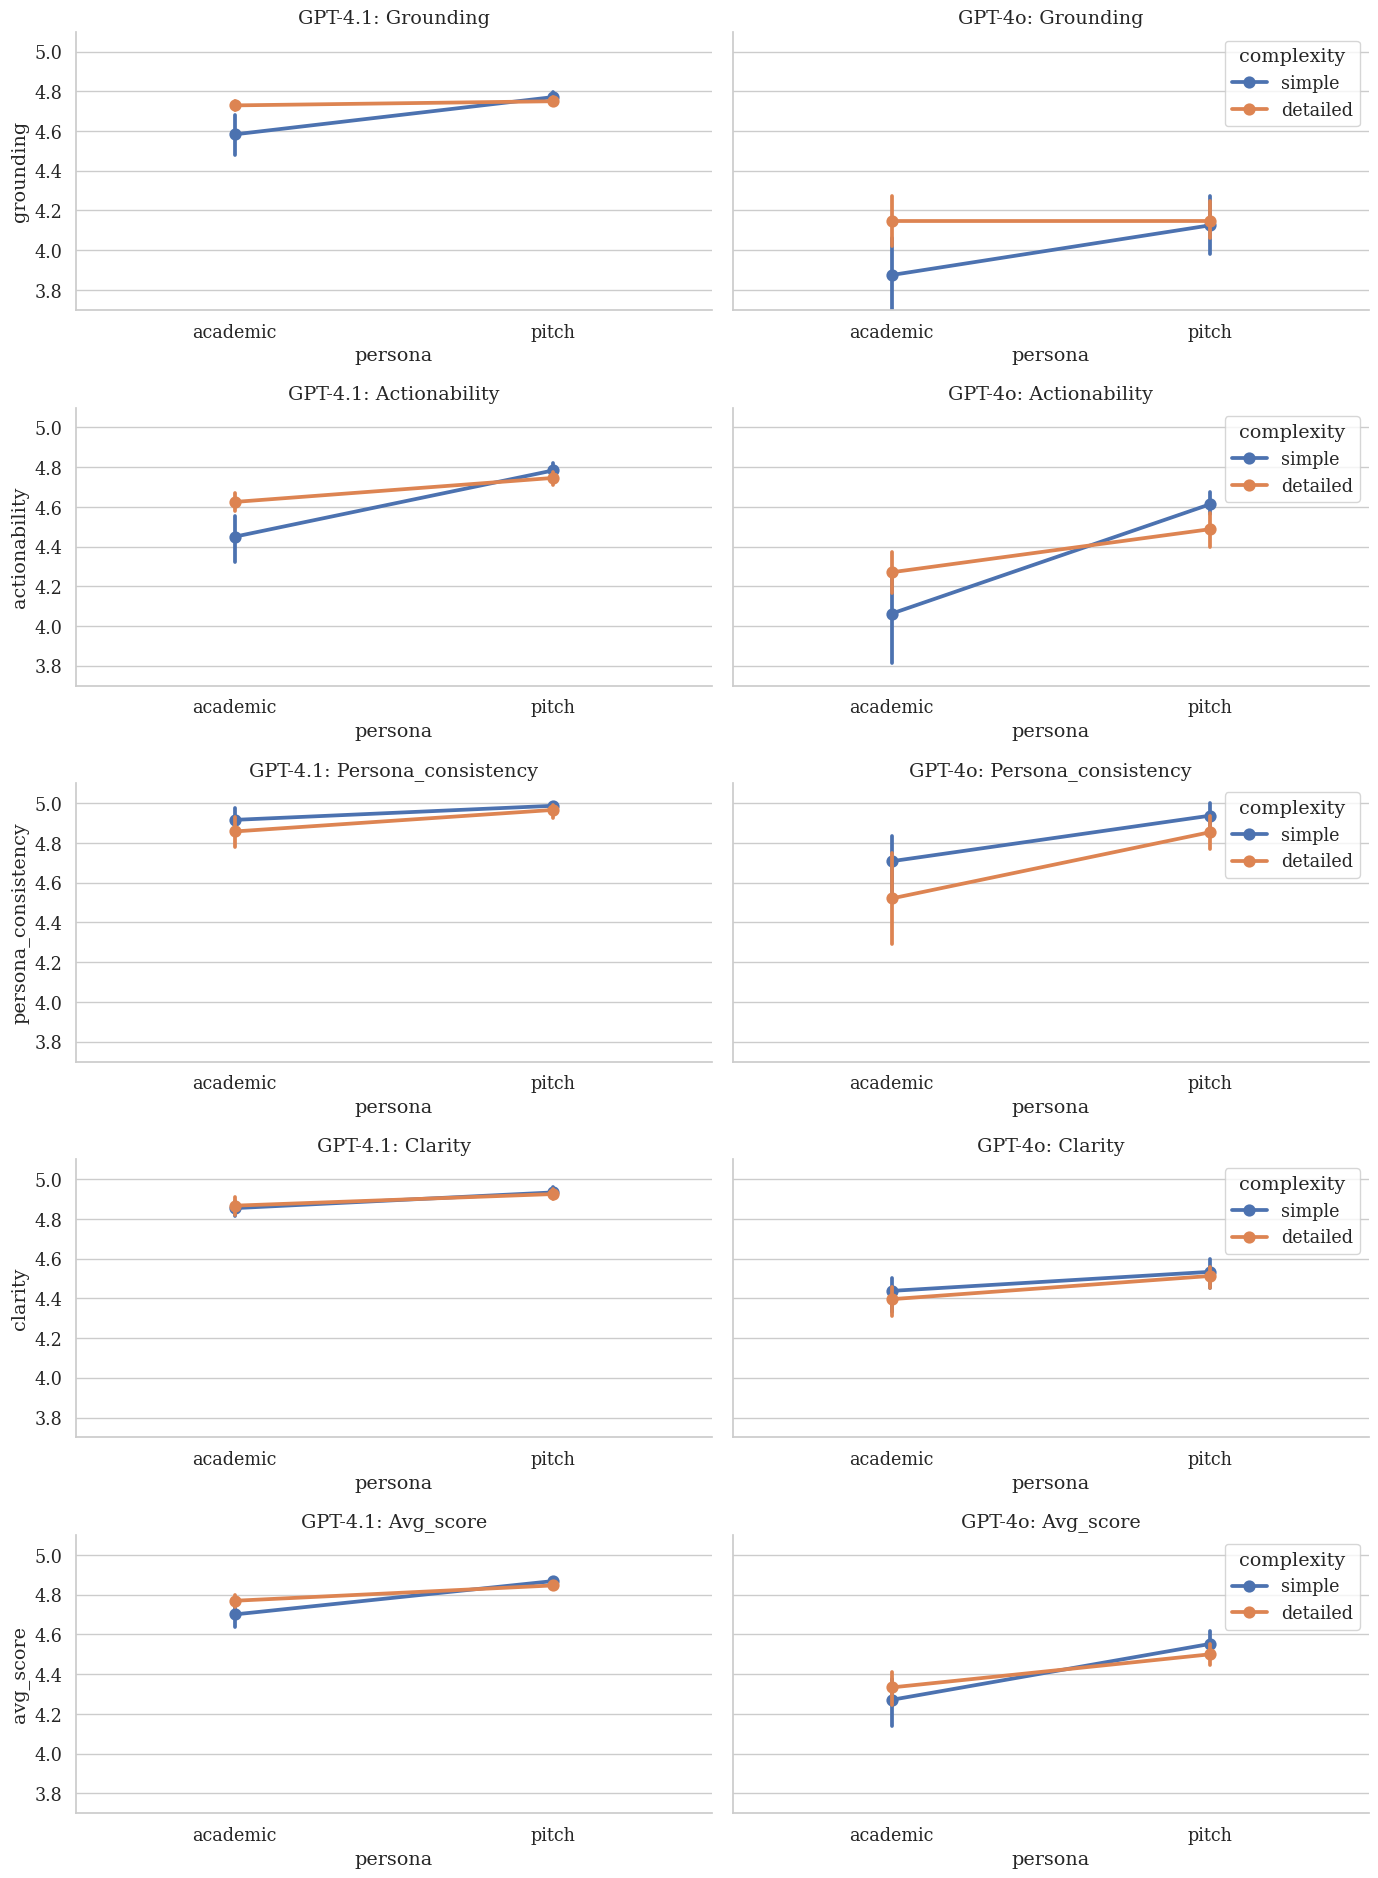

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

df_scale['avg_score'] = df_scale[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)
df_scale4o['avg_score'] = df_scale4o[['grounding', 'actionability', 'persona_consistency', 'clarity']].mean(axis=1)

metrics = ["grounding", "actionability", "persona_consistency", "clarity", "avg_score"]

# We create a grid: Rows = Metrics, Cols = 2 (Left: GPT-4.1, Right: GPT-4o)
fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 20), sharey=True)

for i, metric in enumerate(metrics):
    # --- Column 1: GPT-4.1 ---
    sns.pointplot(
        data=df_scale,
        x="persona",
        y=metric,
        hue="complexity",
        #linestyles="-",
        #markers="o",
        ax=axes[i, 0],
        legend=False

    )
    axes[i, 0].set_title(f"GPT-4.1: {metric.capitalize()}")
    axes[i, 0].set_ylim(3.7, 5.1) # Adjusted slightly for visibility
    
    # --- Column 2: GPT-4o ---
    sns.pointplot(
        data=df_scale4o,
        x="persona",
        y=metric,
        hue="complexity",
        #linestyles="--",
        #markers="s",
        ax=axes[i, 1],

    )
    
    axes[i, 1].set_title(f"GPT-4o: {metric.capitalize()}")

# Add one global legend at the bottom
#handles, labels = axes[0, 0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02), fontsize='large')

# Adjust layout to make room for the bottom legend
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()

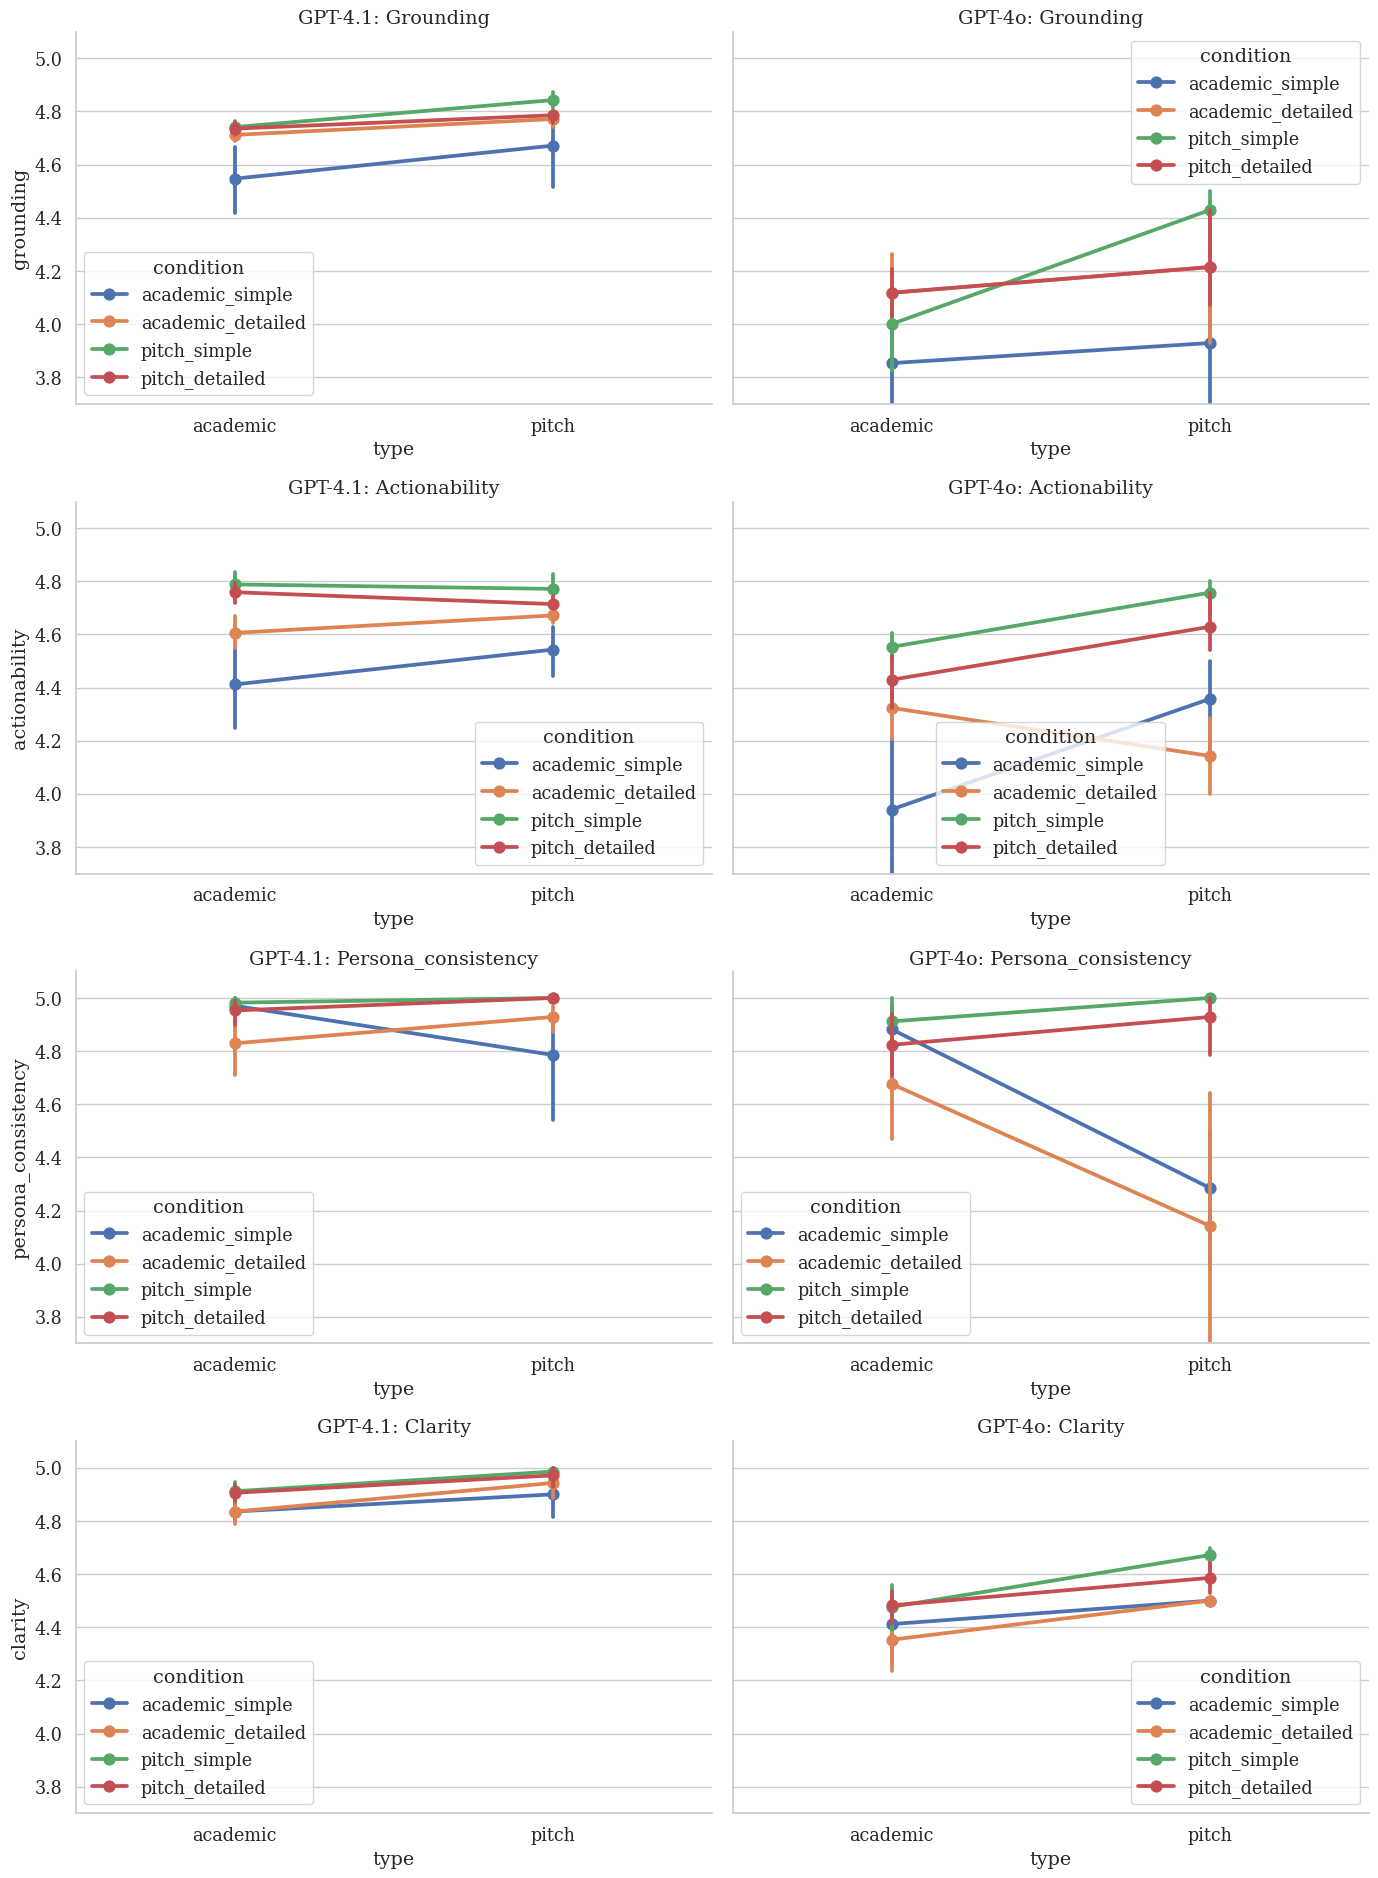

In [216]:
df_scale['condition'] = df_scale['persona'] + "_" + df_scale['complexity']
df_scale4o['condition'] = df_scale4o['persona'] + "_" + df_scale4o['complexity']

metrics = ["grounding", "actionability", "persona_consistency", "clarity"]

# We create a grid: Rows = Metrics, Cols = 2 (Left: GPT-4.1, Right: GPT-4o)
fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 20), sharey=True)

for i, metric in enumerate(metrics):
    # --- Column 1: GPT-4.1 ---
    sns.pointplot(
        data=df_scale,
        x="type",
        y=metric,
        hue="condition",
        #linestyles="-",
        #markers="o",
        ax=axes[i, 0],

    )
    axes[i, 0].set_title(f"GPT-4.1: {metric.capitalize()}")
    axes[i, 0].set_ylim(3.7, 5.1) # Adjusted slightly for visibility
    
    # --- Column 2: GPT-4o ---
    sns.pointplot(
        data=df_scale4o,
        x="type",
        y=metric,
        hue="condition",
        #linestyles="--",
        #markers="s",
        ax=axes[i, 1],

    )
    axes[i, 1].set_title(f"GPT-4o: {metric.capitalize()}")


# Adjust layout to make room for the bottom legend
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()

## Pairwise evaluation 

In [71]:
# plot pairwise comparison results
comparison_counts = df_pair.groupby('comparison').agg({
    'better_grounding': lambda x: (x == 'A').sum(),
    'better_actionability': lambda x: (x == 'A').sum(),
    'better_clarity': lambda x: (x == 'A').sum(),
    'better_overall': lambda x: (x == 'A').sum()
}).reset_index()

comparison_counts


,comparison,better_grounding,better_actionability,better_clarity,better_overall
0,academic_detailed_vs_pitch_detailed,13,5,13,11
1,academic_simple_vs_academic_detailed,16,14,9,15
2,academic_simple_vs_pitch_simple,3,0,3,2
3,pitch_simple_vs_pitch_detailed,23,22,18,22


In [72]:
# plot pairwise comparison results
comparison_counts = df_pair4o.groupby('comparison').agg({
    'better_grounding': lambda x: (x == 'A').sum(),
    'better_actionability': lambda x: (x == 'A').sum(),
    'better_clarity': lambda x: (x == 'A').sum(),
    'better_overall': lambda x: (x == 'A').sum()
}).reset_index()

comparison_counts


,comparison,better_grounding,better_actionability,better_clarity,better_overall
0,academic_detailed_vs_pitch_detailed,14,13,16,15
1,academic_simple_vs_academic_detailed,16,17,17,16
2,academic_simple_vs_pitch_simple,11,11,14,13
3,pitch_simple_vs_pitch_detailed,23,24,23,23


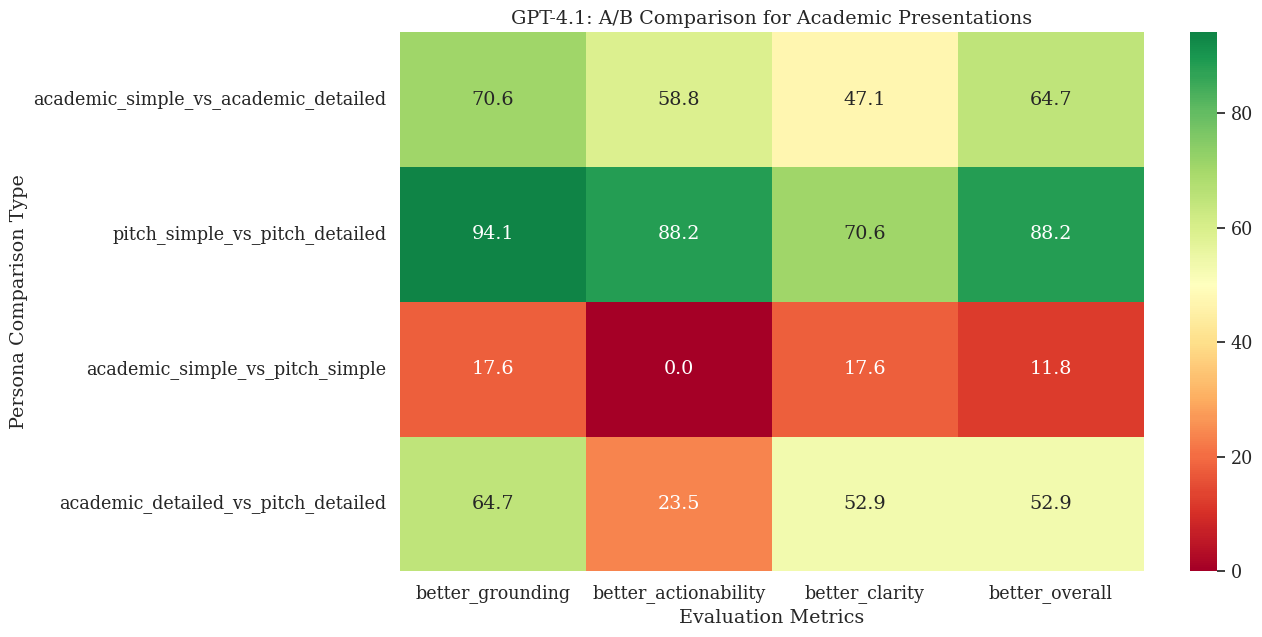

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



def plot_heatmap(df, title="A/B Comparison: Win Rate of Model A (%)"):
    # prepare metrics and data
    metrics = ['better_grounding', 'better_actionability', 'better_clarity', 'better_overall']

    # calculate the % Win Rate for Model A for each comparison type
    heatmap_data = []
    for comp in df['comparison'].unique():
        row = {'comparison': comp}
        comp_group = df[df['comparison'] == comp]
        for metric in metrics:
            # calculate percentage where Model A won
            win_rate_a = (comp_group[metric] == 'A').mean() * 100
            row[metric] = win_rate_a
        heatmap_data.append(row)

    # format into a DataFrame for plotting
    plot_df = pd.DataFrame(heatmap_data).set_index('comparison')

    # generate the heatmap
    plt.figure(figsize=(12, 7))
    sns.heatmap(plot_df, annot=True, cmap='RdYlGn', center=50, fmt='.1f')
    plt.title(title)
    plt.xlabel('Evaluation Metrics')
    plt.ylabel('Persona Comparison Type')
    plt.show()

df = df_pair.copy()
df = df[df['presentation_type']=='academic']
plot_heatmap(df, title="GPT-4.1: A/B Comparison for Academic Presentations")

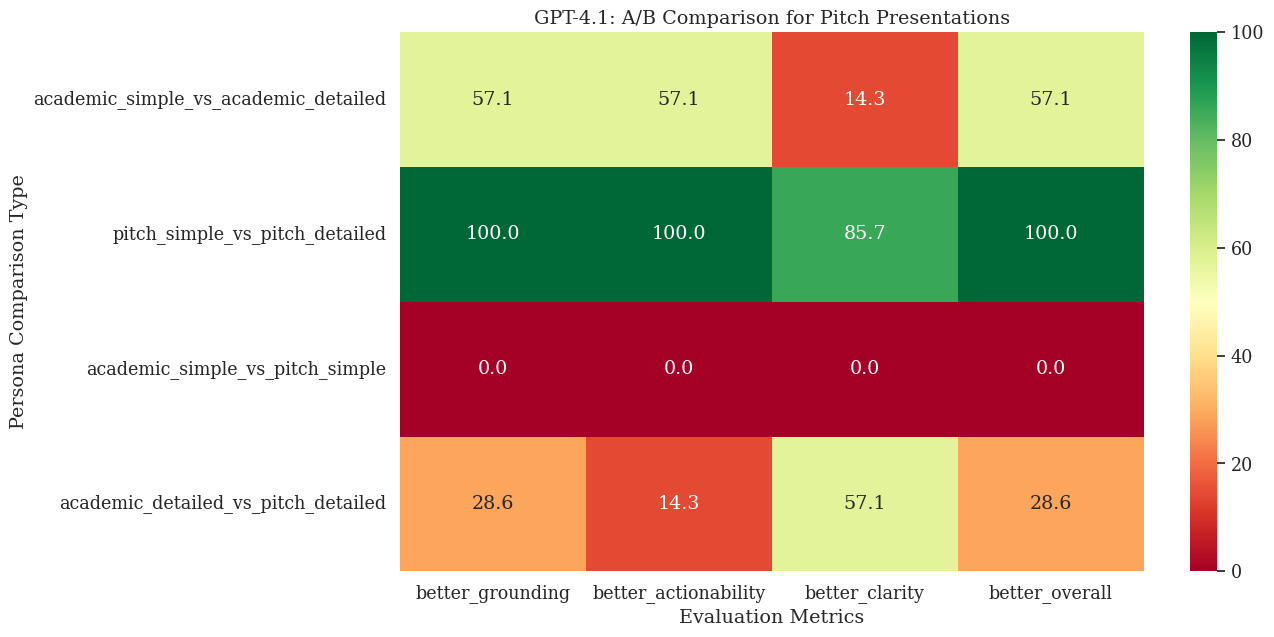

In [51]:
df = df_pair.copy()
df = df[df['presentation_type']=='pitch']
plot_heatmap(df, title="GPT-4.1: A/B Comparison for Pitch Presentations")


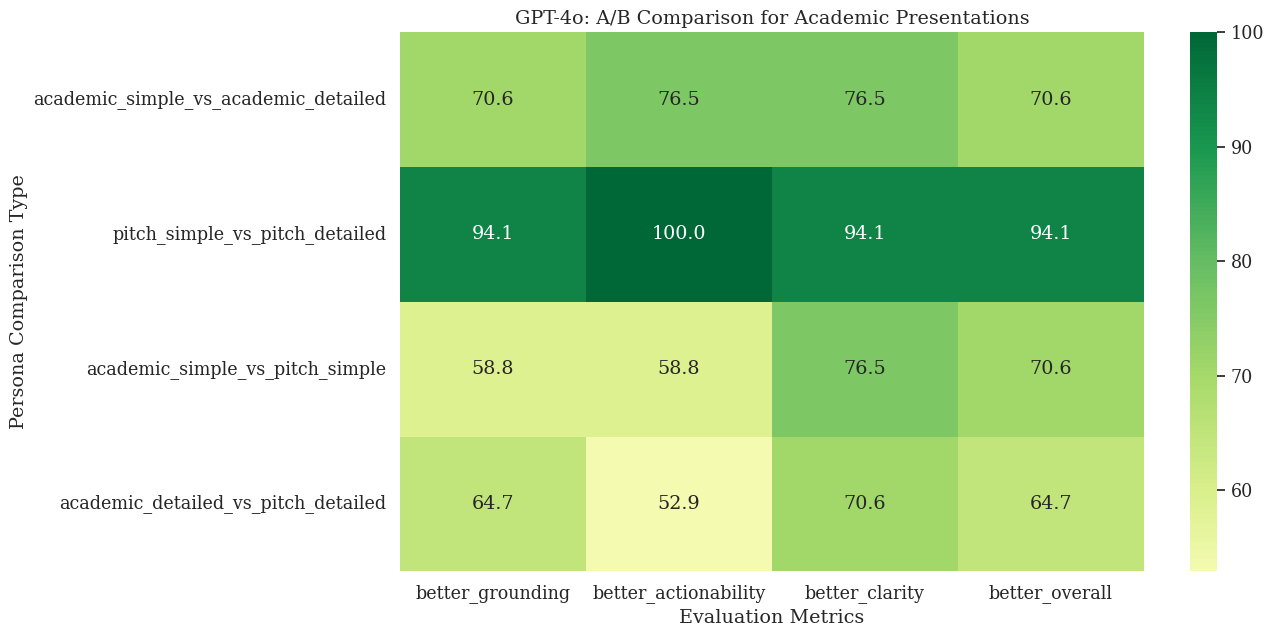

In [48]:
df = df_pair4o.copy()
df = df[df['presentation_type']=='academic']

plot_heatmap(df, title="GPT-4o: A/B Comparison for Academic Presentations")

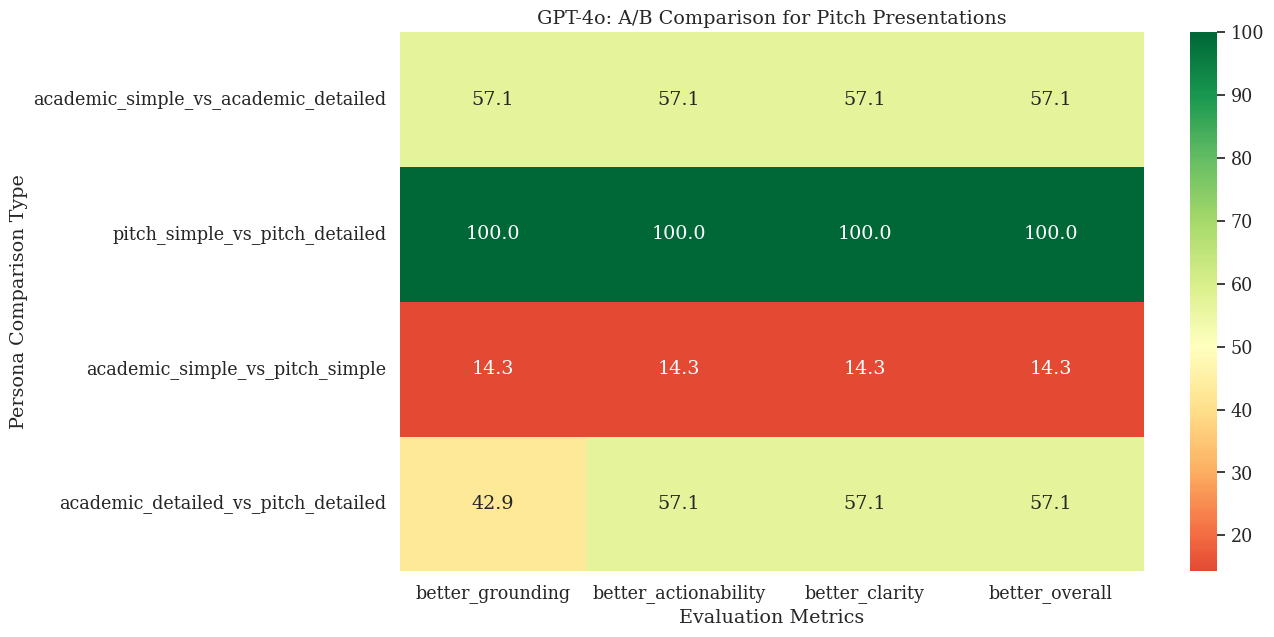

In [49]:
df = df_pair4o.copy()
df = df[df['presentation_type']=='pitch']


plot_heatmap(df, title="GPT-4o: A/B Comparison for Pitch Presentations")
